In [1]:
import pandas as pd
import os
from collections import Counter
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("/usr/xtmp/ap843/data/Data_Entry_2017.csv")
df.head(5)

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
0,00000001_000.png,Cardiomegaly,0,1,058Y,M,PA,2682,2749,0.143,0.143,NaN
1,00000001_001.png,Cardiomegaly|Emphysema,1,1,058Y,M,PA,2894,2729,0.143,0.143,NaN
2,00000001_002.png,Cardiomegaly|Effusion,2,1,058Y,M,PA,2500,2048,0.168,0.168,NaN
3,00000002_000.png,No Finding,0,2,081Y,M,PA,2500,2048,0.171,0.171,NaN
4,00000003_000.png,Hernia,0,3,081Y,F,PA,2582,2991,0.143,0.143,NaN


In [4]:
# Checking for missing values
df.isna().sum()

Image Index                         0
Finding Labels                      0
Follow-up #                         0
Patient ID                          0
Patient Age                         0
Patient Gender                      0
View Position                       0
OriginalImage[Width                 0
Height]                             0
OriginalImagePixelSpacing[x         0
y]                                  0
Unnamed: 11                    112120
dtype: int64

In [5]:
# Dropping unnecessary column
df = df.drop(columns=['Unnamed: 11'])
df.isna().sum()

Image Index                    0
Finding Labels                 0
Follow-up #                    0
Patient ID                     0
Patient Age                    0
Patient Gender                 0
View Position                  0
OriginalImage[Width            0
Height]                        0
OriginalImagePixelSpacing[x    0
y]                             0
dtype: int64

In [6]:
# Checking duplicates and unique images
print(f"Length of data frame: {len(df)}")
unique_images = df['Image Index'].nunique()
print(f"Number of unique images: {unique_images}")

Length of data frame: 112120
Number of unique images: 112120


In [7]:
# Checking label counts
all_labels =df["Finding Labels"].str.split('|').explode()
label_counts = all_labels.value_counts()
print(label_counts)

Finding Labels
No Finding            60412
Infiltration          19870
Effusion              13307
Atelectasis           11535
Nodule                 6323
Mass                   5746
Pneumothorax           5298
Consolidation          4667
Pleural_Thickening     3385
Cardiomegaly           2772
Emphysema              2516
Edema                  2303
Fibrosis               1686
Pneumonia              1353
Hernia                  227
Name: count, dtype: int64


/tmp/ipykernel_2159026/2739223741.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sorted_counts.index, y=sorted_counts.values, palette='crest')


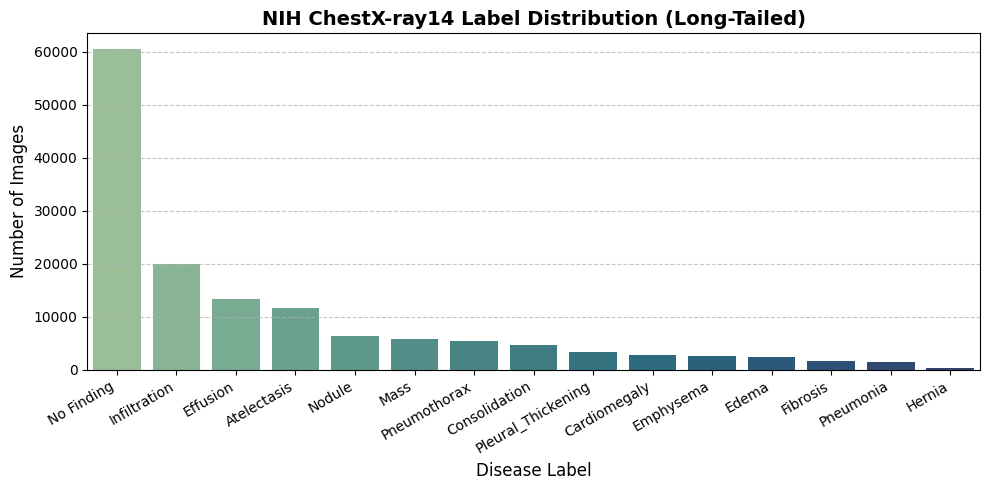

In [15]:
# Improved label count plot with better color scheme
import seaborn as sns
plt.figure(figsize=(10, 5))
sorted_counts = label_counts.sort_values(ascending=False)
sns.barplot(x=sorted_counts.index, y=sorted_counts.values, palette='crest')
plt.title('NIH ChestX-ray14 Label Distribution (Long-Tailed)', fontsize=14, fontweight='bold')
plt.ylabel('Number of Images', fontsize=12)
plt.xlabel('Disease Label', fontsize=12)
plt.xticks(rotation=30, ha='right', fontsize=10)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [10]:
!pip install seaborn